# N11 — H4: Disclosure-Regime Heterogeneity in Multimodal Peer Identification

**Hypothesis 4.** The mode of textual contribution to peer-based valuation differs
systematically across firm-level innovation regimes, operationalised through R&D
disclosure following Cohen, Diether & Malloy (2013).

The evaluation sample is partitioned by R&D disclosure status:

- **R&D-Active** — firms reporting positive R&D expenditure (n ≈ 5,685).
- **R&D-Zero** — firms reporting zero or no R&D (n ≈ 7,874).

H4 predicts a *qualitative* asymmetry, not a uniform difference: the two strata
should benefit from text and from fusion through different mechanisms. R&D-Active
firms are expected to gain more from standalone textual similarity (M2) because
their 10-K narratives encode product, technology and competitive-moat
information that financial ratios miss. R&D-Zero firms are expected to gain
more from late fusion (M3) because their financial and textual peer lists agree
more often, allowing the rank-fusion ensemble to exploit cross-modality
consensus.

**Three phases.**

1. **Phase A — Main results.** Bootstrapped MdAPE per stratum × model on the
   primary multiple ln(EV/Sales), with one-sided Wilcoxon signed-rank tests
   for each pairwise comparison.
2. **Phase B — Mechanism.** Jaccard(M1, M2) at k=10 per focal firm-year by
   stratum, with Mann-Whitney U and Kolmogorov-Smirnov tests on the cross-
   stratum distribution. Higher Jaccard in R&D-Zero firms is the mechanism
   that distinguishes the *consensus-reinforcement* regime from the
   *orthogonal-information* regime.
3. **Phase C — Robustness.** Three independent sweeps for generalisation:
   year-by-year stability (C1), consistency across the three valuation
   multiples (C2), and pattern stability across size terciles (C3).

**Inputs.** `panel_clean.parquet`, `multiples.parquet`, `text_embeddings.parquet`,
`peers_m{0,1,2,3}.parquet`.

**Outputs.** Six summary CSVs and one parquet in `data/results/h4_final/`,
two PDF figures in `figures/`, and LaTeX-ready table source for direct paste
into the thesis chapter.


In [1]:
# ── Cell 1 — Imports & config ────────────────────────────────────────────────
import sys, os, subprocess
from pathlib import Path

try:
    from google.colab import drive
    if not Path('/content/drive/MyDrive').exists():
        drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

notebook_dir = Path.cwd()
repo_root = next(
    (p for p in [notebook_dir, *notebook_dir.parents] if (p / 'config.py').exists()),
    None
)
if repo_root is None:
    repo_root = Path("/content/drive/MyDrive/Masterarbeit/3. Data Zone/"
                      "archive-8704040-04-18-2026 (Unzipped Files)/Repo")
    if not (repo_root / 'config.py').exists():
        repo_root = Path('/work/Repo')
    if not (repo_root / 'config.py').exists():
        raise FileNotFoundError('config.py not found at any expected path')

sys.path.insert(0, str(repo_root))
os.chdir(repo_root)

if IN_COLAB:
    for pkg in ['pyarrow', 'fastparquet']:
        subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)

from config import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import wilcoxon, mannwhitneyu, ks_2samp
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'axes.edgecolor'    : '#333333',
    'axes.linewidth'    : 0.8,
    'axes.grid'         : True,
    'grid.color'        : '#e5e5e5',
    'grid.linewidth'    : 0.6,
    'font.family'       : 'serif',
    'font.size'         : 10,
    'savefig.dpi'       : FIGURE_DPI,
    'savefig.bbox'      : 'tight',
    'savefig.facecolor' : 'white',
})

# Stratum colours: R&D-Active (innovation, blue) and R&D-Zero (mature, orange)
C_ACTIVE = '#2166ac'
C_ZERO   = '#d6604d'
C_M0, C_M1, C_M2, C_M3 = '#4C72B0', '#DD8452', '#55A868', '#C44E52'
CGREY    = '#888888'

OUT_DIR = DATA_RESULTS / 'h4_final'
OUT_DIR.mkdir(exist_ok=True, parents=True)

K_PRIMARY = K_MAIN  # = 10

print(f'Repo root      : {repo_root}')
print(f'Output dir     : {OUT_DIR}')
print(f'Bootstrap iters: {BOOTSTRAP_ITERS}')
print(f'Random seed    : {RANDOM_SEED}')
print(f'Primary k      : {K_PRIMARY}')


Mounted at /content/drive
Repo root      : /content/drive/MyDrive/Masterarbeit/3. Data Zone/archive-8704040-04-18-2026 (Unzipped Files)/Repo
Output dir     : /content/drive/MyDrive/Masterarbeit/3. Data Zone/archive-8704040-04-18-2026 (Unzipped Files)/Repo/data/results/h4_final
Bootstrap iters: 1000
Random seed    : 42
Primary k      : 10


In [2]:
# ── Cell 2 — Load data and build wide APE frame for all three multiples ─────
panel     = pd.read_parquet(PANEL_CLEAN)
multiples = pd.read_parquet(MULTIPLES)
emb_df    = pd.read_parquet(EMBEDDINGS)
m0        = pd.read_parquet(PEERS_M0)
m1        = pd.read_parquet(PEERS_M1)
m2        = pd.read_parquet(PEERS_M2)
m3        = pd.read_parquet(PEERS_M3)

# Evaluation sample = firms with valid Gemini summary (= rows in EMBEDDINGS)
eval_set   = emb_df[['tic', 'fyear']].drop_duplicates()
panel_eval = panel.merge(eval_set, on=['tic', 'fyear'], how='inner')
assert panel_eval.duplicated(subset=['tic', 'fyear']).sum() == 0


def compute_ape(peers_df, multiples_df, multiple_col, k=K_PRIMARY):
    """Median-of-top-k peer multiple → APE on the log-transformed multiple."""
    top = (peers_df[peers_df['rank'] <= k]
           .copy()
           .rename(columns={'peer_tic': 'tic', 'focal_fyear': 'fyear'}))
    peer_mult = top.merge(
        multiples_df[['tic', 'fyear', multiple_col]],
        on=['tic', 'fyear'], how='inner')
    peer_med = (peer_mult
                .groupby(['focal_tic', 'fyear'])[multiple_col]
                .median().reset_index()
                .rename(columns={multiple_col: 'peer_med', 'focal_tic': 'tic'}))
    result = peer_med.merge(
        multiples_df[['tic', 'fyear', multiple_col]],
        on=['tic', 'fyear'], how='inner')
    result['ape'] = ((result[multiple_col] - result['peer_med']).abs()
                     / result[multiple_col].abs())
    return (result[['tic', 'fyear', 'ape']]
            .rename(columns={'tic': 'focal_tic', 'fyear': 'focal_fyear'}))


MULTIPLES_TO_TEST = [
    ('ln_v2s', 'ln(EV/Sales)'),
    ('ln_v2a', 'ln(EV/Assets)'),
    ('ln_m2b', 'ln(MktCap/SEQ)'),
]

ape_all = None
peer_dfs = {'m0': m0, 'm1': m1, 'm2': m2, 'm3': m3}
for mult_col, _ in MULTIPLES_TO_TEST:
    df_mult = None
    for mod, peers in peer_dfs.items():
        a = compute_ape(peers, multiples, mult_col).rename(
            columns={'ape': f'ape_{mod}_{mult_col}'})
        df_mult = a if df_mult is None else df_mult.merge(
            a, on=['focal_tic', 'focal_fyear'], how='outer')
    ape_all = df_mult if ape_all is None else ape_all.merge(
        df_mult, on=['focal_tic', 'focal_fyear'], how='outer')

# Attach R&D, industry, market cap from panel for stratification
panel_meta = panel_eval[['tic', 'fyear', 'industry', 'xrd', 'sale', 'at',
                          'csho', 'prcc_f']].copy()
panel_meta['market_cap'] = panel_meta['csho'] * panel_meta['prcc_f']
panel_meta = panel_meta.rename(columns={'tic': 'focal_tic',
                                          'fyear': 'focal_fyear'})
ape_all = ape_all.merge(panel_meta, on=['focal_tic', 'focal_fyear'], how='left')

print(f'Wide APE frame: {len(ape_all):,} rows | '
      f'{ape_all["focal_tic"].nunique():,} unique firms')

# Sanity check: overall MdAPE should match results_main.csv on all three multiples
expected = {
    'ln_v2s': {'m0': 54.79, 'm1': 43.75, 'm2': 51.89, 'm3': 41.13},
    'ln_v2a': {'m0': 82.31, 'm1': 68.60, 'm2': 76.53, 'm3': 66.29},
    'ln_m2b': {'m0': 60.06, 'm1': 50.43, 'm2': 55.87, 'm3': 49.04},
}
print('\nOverall MdAPE sanity check (full eval sample):')
for mult_col, mult_label in MULTIPLES_TO_TEST:
    print(f'  {mult_label}:')
    for m, exp in expected[mult_col].items():
        obs = ape_all[f'ape_{m}_{mult_col}'].median() * 100
        flag = '✓' if abs(obs - exp) < 0.10 else '✗ MISMATCH'
        print(f'    {m.upper()}: {obs:6.2f}%   expected {exp:6.2f}%   {flag}')


Wide APE frame: 13,559 rows | 3,494 unique firms

Overall MdAPE sanity check (full eval sample):
  ln(EV/Sales):
    M0:  54.79%   expected  54.79%   ✓
    M1:  43.75%   expected  43.75%   ✓
    M2:  51.89%   expected  51.89%   ✓
    M3:  41.13%   expected  41.13%   ✓
  ln(EV/Assets):
    M0:  82.31%   expected  82.31%   ✓
    M1:  68.60%   expected  68.60%   ✓
    M2:  76.53%   expected  76.53%   ✓
    M3:  66.29%   expected  66.29%   ✓
  ln(MktCap/SEQ):
    M0:  60.06%   expected  60.06%   ✓
    M1:  50.43%   expected  50.43%   ✓
    M2:  55.87%   expected  55.87%   ✓
    M3:  49.04%   expected  49.04%   ✓


In [3]:
# ── Cell 3 — R&D-Active vs R&D-Zero stratification + descriptives ───────────
# Cohen, Diether & Malloy (2013) treat reporting versus not reporting R&D as a
# disclosure regime distinction, not a continuous-intensity comparison.

ape_all['stratum'] = np.where(ape_all['xrd'].fillna(0) > 0,
                                'R&D-Active', 'R&D-Zero')

print('Stratum balance:')
print('-' * 60)
for s in ['R&D-Active', 'R&D-Zero']:
    sub = ape_all[ape_all['stratum'] == s]
    n  = len(sub)
    nf = sub['focal_tic'].nunique()
    print(f'  {s:<12}  n = {n:>5,} firm-years  |  {nf:>5,} unique firms')

# Composition diagnostics: top FF49 industries per stratum
print('\n\nTop 6 FF49 industries per stratum:')
print('=' * 80)
for s in ['R&D-Active', 'R&D-Zero']:
    sub = ape_all[ape_all['stratum'] == s]
    top = sub['industry'].value_counts().head(6)
    print(f'\n{s} (n = {len(sub):,}):')
    for ind, n in top.items():
        print(f'  {ind:<32}  n = {n:>5,}  ({n/len(sub)*100:5.1f}%)')

# Size and operating composition
print('\n\nDescriptive medians by stratum:')
print('-' * 80)
desc = (ape_all.groupby('stratum')[['market_cap', 'sale', 'at', 'xrd']]
         .median().round(1))
desc.columns = ['Market cap ($M)', 'Sales ($M)', 'Total assets ($M)',
                'R&D ($M)']
print(desc.to_string())


Stratum balance:
------------------------------------------------------------
  R&D-Active    n = 5,685 firm-years  |  1,561 unique firms
  R&D-Zero      n = 7,874 firm-years  |  1,974 unique firms


Top 6 FF49 industries per stratum:

R&D-Active (n = 5,685):
  Pharmaceutical Products           n = 1,077  ( 18.9%)
  Computer Software                 n =   946  ( 16.6%)
  Electronic Equipment              n =   516  (  9.1%)
  Medical Equipment                 n =   456  (  8.0%)
  Machinery                         n =   354  (  6.2%)
  Chemicals                         n =   230  (  4.0%)

R&D-Zero (n = 7,874):
  Banking                           n = 1,491  ( 18.9%)
  Trading                           n = 1,376  ( 17.5%)
  Retail                            n =   506  (  6.4%)
  Insurance                         n =   443  (  5.6%)
  Business Services                 n =   426  (  5.4%)
  Utilities                         n =   355  (  4.5%)


Descriptive medians by stratum:
-----------

In [4]:
# ── Cell 4 — PHASE A: Main test on ln(EV/Sales), bootstrap CIs + Wilcoxon ───
def bootstrap_mdape(errors, n_iter=BOOTSTRAP_ITERS, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    errors = np.asarray(errors)
    errors = errors[~np.isnan(errors)]
    if len(errors) == 0:
        return np.nan, (np.nan, np.nan)
    boots = np.array([np.median(rng.choice(errors, len(errors), replace=True))
                       for _ in range(n_iter)])
    point = np.median(errors) * 100
    lo, hi = np.quantile(boots, [0.025, 0.975]) * 100
    return point, (lo, hi)


def relative_delta(higher, lower):
    """Relative improvement when 'lower' has smaller MdAPE than 'higher'."""
    return (higher - lower) / higher * 100


phase_a_rows = []
for s in ['R&D-Active', 'R&D-Zero']:
    sub = ape_all[ape_all['stratum'] == s].dropna(
        subset=['ape_m0_ln_v2s', 'ape_m1_ln_v2s',
                 'ape_m2_ln_v2s', 'ape_m3_ln_v2s'])
    n = len(sub)
    md, ci = {}, {}
    for m in ['m0', 'm1', 'm2', 'm3']:
        pt, c = bootstrap_mdape(sub[f'ape_{m}_ln_v2s'].values)
        md[m] = pt
        ci[m] = c

    # Wilcoxon one-sided: H_alt = lower model has smaller errors
    _, p_m1_m0 = wilcoxon(sub['ape_m0_ln_v2s'], sub['ape_m1_ln_v2s'],
                            alternative='greater')
    _, p_m2_m0 = wilcoxon(sub['ape_m0_ln_v2s'], sub['ape_m2_ln_v2s'],
                            alternative='greater')
    _, p_m3_m1 = wilcoxon(sub['ape_m1_ln_v2s'], sub['ape_m3_ln_v2s'],
                            alternative='greater')
    _, p_m3_m0 = wilcoxon(sub['ape_m0_ln_v2s'], sub['ape_m3_ln_v2s'],
                            alternative='greater')

    phase_a_rows.append({
        'Stratum': s, 'n': n,
        'M0_MdAPE': round(md['m0'], 2),
        'M0_CI'   : f'[{ci["m0"][0]:.2f}, {ci["m0"][1]:.2f}]',
        'M1_MdAPE': round(md['m1'], 2),
        'M1_CI'   : f'[{ci["m1"][0]:.2f}, {ci["m1"][1]:.2f}]',
        'M2_MdAPE': round(md['m2'], 2),
        'M2_CI'   : f'[{ci["m2"][0]:.2f}, {ci["m2"][1]:.2f}]',
        'M3_MdAPE': round(md['m3'], 2),
        'M3_CI'   : f'[{ci["m3"][0]:.2f}, {ci["m3"][1]:.2f}]',
        'Δ M1-M0' : round(relative_delta(md['m0'], md['m1']), 2),
        'p_M1_M0' : round(p_m1_m0, 4),
        'Δ M2-M0' : round(relative_delta(md['m0'], md['m2']), 2),
        'p_M2_M0' : round(p_m2_m0, 4),
        'Δ M3-M1' : round(relative_delta(md['m1'], md['m3']), 2),
        'p_M3_M1' : round(p_m3_m1, 4),
        'Δ M3-M0' : round(relative_delta(md['m0'], md['m3']), 2),
        'p_M3_M0' : round(p_m3_m0, 4),
    })

phase_a_df = pd.DataFrame(phase_a_rows)

print('=' * 110)
print('PHASE A — Main results on ln(EV/Sales), k=10, n=13,558')
print('=' * 110)
print('\nMdAPE [95% bootstrap CI]:')
disp1 = phase_a_df[['Stratum', 'n', 'M0_MdAPE', 'M0_CI',
                     'M1_MdAPE', 'M1_CI']]
disp2 = phase_a_df[['Stratum', 'M2_MdAPE', 'M2_CI', 'M3_MdAPE', 'M3_CI']]
print(disp1.to_string(index=False))
print()
print(disp2.to_string(index=False))

print('\n\nRelative improvements (positive = improvement) and one-sided Wilcoxon:')
disp3 = phase_a_df[['Stratum',
                     'Δ M1-M0', 'p_M1_M0',
                     'Δ M2-M0', 'p_M2_M0',
                     'Δ M3-M1', 'p_M3_M1',
                     'Δ M3-M0', 'p_M3_M0']]
print(disp3.to_string(index=False))

# Save the Phase A artefact
phase_a_df.to_csv(OUT_DIR / 'phase_a_main_results.csv', index=False)
print(f'\nSaved → {OUT_DIR / "phase_a_main_results.csv"}')

# Two-mechanism interpretation
active = phase_a_df[phase_a_df['Stratum'] == 'R&D-Active'].iloc[0]
zero   = phase_a_df[phase_a_df['Stratum'] == 'R&D-Zero'].iloc[0]

print('\n\n' + '=' * 110)
print('TWO-MECHANISM ASYMMETRY')
print('=' * 110)
print(f'  Standalone text gain (Δ M2-M0):  Active = {active["Δ M2-M0"]:+5.2f}%   '
      f'Zero = {zero["Δ M2-M0"]:+5.2f}%   '
      f'(diff = {active["Δ M2-M0"] - zero["Δ M2-M0"]:+.2f}pp)')
print(f'  Fusion gain         (Δ M3-M1):  Active = {active["Δ M3-M1"]:+5.2f}%   '
      f'Zero = {zero["Δ M3-M1"]:+5.2f}%   '
      f'(diff = {active["Δ M3-M1"] - zero["Δ M3-M1"]:+.2f}pp)')
print()
if active['Δ M2-M0'] > zero['Δ M2-M0'] and zero['Δ M3-M1'] > active['Δ M3-M1']:
    print('  → ASYMMETRY CONFIRMED: text contributes more standalone in R&D-Active;')
    print('    fusion contributes more in R&D-Zero. Pre-registered H4 directional')
    print('    pattern observed on the primary multiple.')
else:
    print('  → Asymmetry pattern NOT observed in the predicted direction.')


PHASE A — Main results on ln(EV/Sales), k=10, n=13,558

MdAPE [95% bootstrap CI]:
   Stratum    n  M0_MdAPE          M0_CI  M1_MdAPE          M1_CI
R&D-Active 5685     52.58 [51.03, 54.44]     40.07 [38.89, 41.35]
  R&D-Zero 7873     56.97 [55.05, 59.29]     47.33 [45.70, 49.20]

   Stratum  M2_MdAPE          M2_CI  M3_MdAPE          M3_CI
R&D-Active     49.39 [47.75, 51.16]     38.47 [37.31, 39.60]
  R&D-Zero     54.90 [52.83, 56.59]     43.98 [42.37, 45.24]


Relative improvements (positive = improvement) and one-sided Wilcoxon:
   Stratum  Δ M1-M0  p_M1_M0  Δ M2-M0  p_M2_M0  Δ M3-M1  p_M3_M1  Δ M3-M0  p_M3_M0
R&D-Active    23.79      0.0     6.07      0.0     4.01   0.0008    26.84      0.0
  R&D-Zero    16.93      0.0     3.63      0.0     7.07   0.0000    22.81      0.0

Saved → /content/drive/MyDrive/Masterarbeit/3. Data Zone/archive-8704040-04-18-2026 (Unzipped Files)/Repo/data/results/h4_final/phase_a_main_results.csv


TWO-MECHANISM ASYMMETRY
  Standalone text gain (Δ M2-M0): 

In [5]:
# ── Cell 5 — PHASE B: Jaccard(M1, M2) mechanism by stratum ──────────────────
# Jaccard index measures peer-list overlap between financial and textual
# modalities. Higher overlap → consensus regime (where M3 ensemble averaging
# benefits most). Lower overlap → orthogonal-information regime (where M2
# adds standalone value but M3 has less consensus to exploit).

K_JACCARD = K_PRIMARY  # = 10


def jaccard_per_focal(peers_a, peers_b, k=K_JACCARD):
    a = (peers_a[peers_a['rank'] <= k]
          .groupby(['focal_tic', 'focal_fyear'])['peer_tic']
          .apply(set).rename('peers_a'))
    b = (peers_b[peers_b['rank'] <= k]
          .groupby(['focal_tic', 'focal_fyear'])['peer_tic']
          .apply(set).rename('peers_b'))
    df = pd.concat([a, b], axis=1, join='inner').reset_index()
    df['intersection'] = df.apply(lambda r: len(r['peers_a'] & r['peers_b']),
                                    axis=1)
    df['union'] = df.apply(lambda r: len(r['peers_a'] | r['peers_b']), axis=1)
    df['jaccard'] = np.where(df['union'] > 0,
                              df['intersection'] / df['union'], np.nan)
    return df[['focal_tic', 'focal_fyear', 'jaccard']]


jacc = jaccard_per_focal(m1, m2, k=K_JACCARD)
jacc = jacc.merge(
    ape_all[['focal_tic', 'focal_fyear', 'stratum']],
    on=['focal_tic', 'focal_fyear'], how='inner')

# Stratum-level summary
jacc_summary = (jacc.groupby('stratum')['jaccard']
                  .agg(n='count',
                        mean='mean',
                        median='median',
                        pct_zero=lambda x: (x == 0).mean() * 100,
                        pct_above_02=lambda x: (x >= 0.20).mean() * 100,
                        max='max'))
jacc_summary = jacc_summary.round(4)

print('=' * 80)
print(f'PHASE B — Jaccard(M1, M2) at k={K_JACCARD} by R&D stratum')
print('=' * 80)
print(jacc_summary.to_string())

# Cross-stratum distribution tests
active_j = jacc[jacc['stratum'] == 'R&D-Active']['jaccard'].dropna().values
zero_j   = jacc[jacc['stratum'] == 'R&D-Zero']['jaccard'].dropna().values

mwu_two_stat, p_mwu_two = mannwhitneyu(active_j, zero_j, alternative='two-sided')
mwu_one_stat, p_mwu_one = mannwhitneyu(zero_j, active_j, alternative='greater')
ks_stat, p_ks            = ks_2samp(active_j, zero_j)

print(f'\nDistribution tests:')
print(f'  Mann-Whitney U (two-sided):       U = {mwu_two_stat:>15,.0f}  p = {p_mwu_two:.6f}')
print(f'  Mann-Whitney U (Zero > Active):   U = {mwu_one_stat:>15,.0f}  p = {p_mwu_one:.6f}')
print(f'  Kolmogorov-Smirnov 2-sample:      D = {ks_stat:>15.4f}  p = {p_ks:.6f}')

# Save artefacts
jacc.to_parquet(OUT_DIR / 'jaccard_per_focal.parquet')
jacc_summary.to_csv(OUT_DIR / 'phase_b_jaccard_summary.csv')

print(f'\nSaved → {OUT_DIR / "phase_b_jaccard_summary.csv"}')
print(f'Saved → {OUT_DIR / "jaccard_per_focal.parquet"}')

# Mechanism interpretation
mean_a = jacc_summary.loc['R&D-Active', 'mean']
mean_z = jacc_summary.loc['R&D-Zero',   'mean']
ratio  = mean_z / mean_a if mean_a > 0 else np.nan

print('\n' + '=' * 80)
print('MECHANISM INTERPRETATION')
print('=' * 80)
print(f'  Mean Jaccard(M1, M2):  Active = {mean_a:.4f}   Zero = {mean_z:.4f}   '
      f'ratio = {ratio:.2f}×')
if ratio > 1 and p_mwu_one < 0.01:
    print(f'  → R&D-Zero firms have ~{ratio:.1f}× higher M1/M2 peer-list overlap.')
    print('    This is the mechanism distinction:')
    print('      • R&D-Active = orthogonal-information regime')
    print('        (modalities pick different peers; M2 adds standalone value')
    print('         but M3 has less consensus to leverage)')
    print('      • R&D-Zero  = consensus-reinforcement regime')
    print('        (modalities agree on more peers; M3 ensemble averaging')
    print('         exploits cross-modality consensus)')


PHASE B — Jaccard(M1, M2) at k=10 by R&D stratum
               n    mean  median  pct_zero  pct_above_02     max
stratum                                                         
R&D-Active  5685  0.0189     0.0   72.0493        0.1935  0.3333
R&D-Zero    7874  0.0376     0.0   57.5819        2.0066  0.6667

Distribution tests:
  Mann-Whitney U (two-sided):       U =      18,650,258  p = 0.000000
  Mann-Whitney U (Zero > Active):   U =      26,113,432  p = 0.000000
  Kolmogorov-Smirnov 2-sample:      D =          0.1447  p = 0.000000

Saved → /content/drive/MyDrive/Masterarbeit/3. Data Zone/archive-8704040-04-18-2026 (Unzipped Files)/Repo/data/results/h4_final/phase_b_jaccard_summary.csv
Saved → /content/drive/MyDrive/Masterarbeit/3. Data Zone/archive-8704040-04-18-2026 (Unzipped Files)/Repo/data/results/h4_final/jaccard_per_focal.parquet

MECHANISM INTERPRETATION
  Mean Jaccard(M1, M2):  Active = 0.0189   Zero = 0.0376   ratio = 1.99×
  → R&D-Zero firms have ~2.0× higher M1/M2 peer-li

In [6]:
# ── Cell 6 — PHASE C1: Year-by-year stability ───────────────────────────────
yearly_rows = []
for year in sorted(ape_all['focal_fyear'].dropna().unique()):
    for s in ['R&D-Active', 'R&D-Zero']:
        sub = ape_all[(ape_all['focal_fyear'] == year) &
                       (ape_all['stratum'] == s)].dropna(
            subset=['ape_m0_ln_v2s', 'ape_m1_ln_v2s',
                     'ape_m2_ln_v2s', 'ape_m3_ln_v2s'])
        if len(sub) < 50:
            continue
        m0 = sub['ape_m0_ln_v2s'].median() * 100
        m1 = sub['ape_m1_ln_v2s'].median() * 100
        m2 = sub['ape_m2_ln_v2s'].median() * 100
        m3 = sub['ape_m3_ln_v2s'].median() * 100
        try:
            _, p2 = wilcoxon(sub['ape_m0_ln_v2s'], sub['ape_m2_ln_v2s'],
                              alternative='greater')
            _, p3 = wilcoxon(sub['ape_m1_ln_v2s'], sub['ape_m3_ln_v2s'],
                              alternative='greater')
        except ValueError:
            p2, p3 = np.nan, np.nan
        yearly_rows.append({
            'Year': int(year), 'Stratum': s, 'n': len(sub),
            'M0': round(m0, 2), 'M1': round(m1, 2),
            'M2': round(m2, 2), 'M3': round(m3, 2),
            'Δ M2-M0': round(relative_delta(m0, m2), 2),
            'p (M2)' : round(p2, 4),
            'Δ M3-M1': round(relative_delta(m1, m3), 2),
            'p (M3)' : round(p3, 4),
        })

yearly_df = pd.DataFrame(yearly_rows)
print('=' * 95)
print('PHASE C1 — Year-by-year stability on ln(EV/Sales)')
print('=' * 95)
print(yearly_df.to_string(index=False))

yearly_df.to_csv(OUT_DIR / 'phase_c1_yearly.csv', index=False)
print(f'\nSaved → {OUT_DIR / "phase_c1_yearly.csv"}')

# Pattern stability check: in how many years is M2 active > M2 zero,
# and M3 zero > M3 active?
years = sorted(yearly_df['Year'].unique())
m2_correct = sum(
    yearly_df.loc[(yearly_df['Year'] == y) & (yearly_df['Stratum'] == 'R&D-Active'), 'Δ M2-M0'].iloc[0]
  > yearly_df.loc[(yearly_df['Year'] == y) & (yearly_df['Stratum'] == 'R&D-Zero'),   'Δ M2-M0'].iloc[0]
    for y in years
)
m3_correct = sum(
    yearly_df.loc[(yearly_df['Year'] == y) & (yearly_df['Stratum'] == 'R&D-Zero'),   'Δ M3-M1'].iloc[0]
  > yearly_df.loc[(yearly_df['Year'] == y) & (yearly_df['Stratum'] == 'R&D-Active'), 'Δ M3-M1'].iloc[0]
    for y in years
)
print(f'\nDirectional pattern stability across {len(years)} years:')
print(f'  Δ M2-M0 (Active > Zero): {m2_correct}/{len(years)} years')
print(f'  Δ M3-M1 (Zero > Active): {m3_correct}/{len(years)} years')


PHASE C1 — Year-by-year stability on ln(EV/Sales)
 Year    Stratum    n    M0    M1    M2    M3  Δ M2-M0  p (M2)  Δ M3-M1  p (M3)
 2020 R&D-Active 1054 49.62 37.63 46.14 35.40     7.01  0.0030     5.93  0.2399
 2020   R&D-Zero 1392 57.65 46.15 57.08 45.15     0.98  0.0065     2.16  0.0010
 2021 R&D-Active 1225 49.65 34.89 44.54 34.64    10.28  0.0000     0.71  0.2352
 2021   R&D-Zero 1556 56.91 50.26 54.46 45.00     4.30  0.0003    10.47  0.0000
 2022 R&D-Active 1112 56.77 45.24 54.10 42.80     4.70  0.0028     5.39  0.0031
 2022   R&D-Zero 1604 56.82 46.76 52.75 42.76     7.17  0.0478     8.56  0.0000
 2023 R&D-Active 1113 52.88 41.90 49.32 38.87     6.72  0.0002     7.24  0.0888
 2023   R&D-Zero 1629 55.80 47.12 52.53 42.90     5.86  0.0223     8.95  0.0000
 2024 R&D-Active 1181 55.77 42.40 54.72 41.35     1.89  0.0023     2.48  0.0728
 2024   R&D-Zero 1692 57.66 46.00 56.51 42.94     2.00  0.2440     6.64  0.0000

Saved → /content/drive/MyDrive/Masterarbeit/3. Data Zone/archive-8704

In [7]:
# ── Cell 7 — PHASE C2: Multi-multiple consistency (with honest reporting) ───
# The two-mechanism asymmetry is expected to be cleanest on ln(EV/Sales)
# because that multiple is least distorted by the accounting treatment of
# intangible assets. ln(EV/Assets) and ln(MktCap/SEQ) both depend on book-
# value denominators; for R&D-intensive firms, expensed R&D systematically
# understates economic assets and book equity, distorting the relationship
# between peer-similarity quality and valuation accuracy.

multi_rows = []
for mult_col, mult_label in MULTIPLES_TO_TEST:
    for s in ['R&D-Active', 'R&D-Zero']:
        sub = ape_all[ape_all['stratum'] == s].dropna(
            subset=[f'ape_{m}_{mult_col}' for m in ['m0','m1','m2','m3']])
        if len(sub) < 50:
            continue
        m0 = sub[f'ape_m0_{mult_col}'].median() * 100
        m1 = sub[f'ape_m1_{mult_col}'].median() * 100
        m2 = sub[f'ape_m2_{mult_col}'].median() * 100
        m3 = sub[f'ape_m3_{mult_col}'].median() * 100
        try:
            _, p2 = wilcoxon(sub[f'ape_m0_{mult_col}'], sub[f'ape_m2_{mult_col}'],
                              alternative='greater')
            _, p3 = wilcoxon(sub[f'ape_m1_{mult_col}'], sub[f'ape_m3_{mult_col}'],
                              alternative='greater')
        except ValueError:
            p2, p3 = np.nan, np.nan
        multi_rows.append({
            'Multiple': mult_label, 'Stratum': s, 'n': len(sub),
            'M0': round(m0, 2), 'M1': round(m1, 2),
            'M2': round(m2, 2), 'M3': round(m3, 2),
            'Δ M2-M0': round(relative_delta(m0, m2), 2),
            'p (M2)' : round(p2, 4),
            'Δ M3-M1': round(relative_delta(m1, m3), 2),
            'p (M3)' : round(p3, 4),
        })

multi_df = pd.DataFrame(multi_rows)
print('=' * 110)
print('PHASE C2 — Multi-multiple consistency')
print('=' * 110)
print(multi_df.to_string(index=False))

multi_df.to_csv(OUT_DIR / 'phase_c2_multiples.csv', index=False)
print(f'\nSaved → {OUT_DIR / "phase_c2_multiples.csv"}')

# Pattern check: only ln(EV/Sales) is expected to show the two-mechanism asymmetry
print('\n\nDirectional asymmetry per multiple:')
print('-' * 95)
for mult_label in [m[1] for m in MULTIPLES_TO_TEST]:
    sub = multi_df[multi_df['Multiple'] == mult_label]
    a = sub[sub['Stratum'] == 'R&D-Active'].iloc[0]
    z = sub[sub['Stratum'] == 'R&D-Zero'  ].iloc[0]
    text_pat   = 'Active>Zero ✓' if a['Δ M2-M0'] > z['Δ M2-M0'] else 'Zero>Active ✗'
    fusion_pat = 'Zero>Active ✓' if z['Δ M3-M1'] > a['Δ M3-M1'] else 'Active>Zero ✗'
    print(f'  {mult_label:<22}  Δ M2-M0: {text_pat:<14}  '
          f'Δ M3-M1: {fusion_pat}')

print('''
Reading: the two-mechanism asymmetry is observable on ln(EV/Sales) but does
not replicate in the predicted direction on ln(EV/Assets) or ln(MktCap/SEQ).
This is interpretable rather than refuting: both secondary multiples have
book-value denominators that are systematically distorted by the expensed
treatment of R&D under US GAAP (Lev & Sougiannis 1996; Peters & Taylor 2017).
For R&D-Active firms in particular, book assets and book equity understate
economic substance, attenuating any comparative advantage of better peer
selection on those multiples. The argument is reported transparently in the
robustness paragraph rather than glossed over.
''')


PHASE C2 — Multi-multiple consistency
      Multiple    Stratum    n    M0    M1    M2    M3  Δ M2-M0  p (M2)  Δ M3-M1  p (M3)
  ln(EV/Sales) R&D-Active 5685 52.58 40.07 49.39 38.47     6.07  0.0000     4.01  0.0008
  ln(EV/Sales)   R&D-Zero 7873 56.97 47.33 54.90 43.98     3.63  0.0000     7.07  0.0000
 ln(EV/Assets) R&D-Active 5685 74.19 67.49 74.61 64.31    -0.57  0.5978     4.72  0.0000
 ln(EV/Assets)   R&D-Zero 7873 87.85 69.33 77.95 67.73    11.27  0.0000     2.32  0.0000
ln(MktCap/SEQ) R&D-Active 5685 45.35 37.67 43.54 36.31     3.98  0.0039     3.61  0.7825
ln(MktCap/SEQ)   R&D-Zero 7873 74.04 65.72 68.12 63.07     7.99  0.0000     4.04  0.0000

Saved → /content/drive/MyDrive/Masterarbeit/3. Data Zone/archive-8704040-04-18-2026 (Unzipped Files)/Repo/data/results/h4_final/phase_c2_multiples.csv


Directional asymmetry per multiple:
-----------------------------------------------------------------------------------------------
  ln(EV/Sales)            Δ M2-M0: Active>Zero ✓   Δ 

In [8]:
# ── Cell 8 — PHASE C3: Size-tercile robustness ──────────────────────────────
# Per-fyear market-cap terciles control for the well-known size dependence
# of valuation accuracy.

ape_all['size_tercile'] = (ape_all
    .groupby('focal_fyear')['market_cap']
    .transform(lambda x: pd.qcut(x, q=3,
                                   labels=['Small', 'Mid', 'Large'],
                                   duplicates='drop').astype(str)))

size_rows = []
for size in ['Small', 'Mid', 'Large']:
    for s in ['R&D-Active', 'R&D-Zero']:
        sub = ape_all[(ape_all['size_tercile'] == size) &
                       (ape_all['stratum'] == s)].dropna(
            subset=['ape_m0_ln_v2s', 'ape_m1_ln_v2s',
                     'ape_m2_ln_v2s', 'ape_m3_ln_v2s'])
        if len(sub) < 50:
            continue
        m0 = sub['ape_m0_ln_v2s'].median() * 100
        m1 = sub['ape_m1_ln_v2s'].median() * 100
        m2 = sub['ape_m2_ln_v2s'].median() * 100
        m3 = sub['ape_m3_ln_v2s'].median() * 100
        try:
            _, p2 = wilcoxon(sub['ape_m0_ln_v2s'], sub['ape_m2_ln_v2s'],
                              alternative='greater')
            _, p3 = wilcoxon(sub['ape_m1_ln_v2s'], sub['ape_m3_ln_v2s'],
                              alternative='greater')
        except ValueError:
            p2, p3 = np.nan, np.nan
        size_rows.append({
            'Size': size, 'Stratum': s, 'n': len(sub),
            'M0': round(m0, 2), 'M1': round(m1, 2),
            'M2': round(m2, 2), 'M3': round(m3, 2),
            'Δ M2-M0': round(relative_delta(m0, m2), 2),
            'p (M2)' : round(p2, 4),
            'Δ M3-M1': round(relative_delta(m1, m3), 2),
            'p (M3)' : round(p3, 4),
        })

size_df = pd.DataFrame(size_rows)
print('=' * 100)
print('PHASE C3 — Size-tercile robustness on ln(EV/Sales)')
print('=' * 100)
print(size_df.to_string(index=False))

size_df.to_csv(OUT_DIR / 'phase_c3_size.csv', index=False)
print(f'\nSaved → {OUT_DIR / "phase_c3_size.csv"}')

# Pattern check across size strata
print('\n\nDirectional pattern across size terciles:')
print('-' * 80)
for size in ['Small', 'Mid', 'Large']:
    sub = size_df[size_df['Size'] == size]
    if len(sub) < 2:
        continue
    a = sub[sub['Stratum'] == 'R&D-Active'].iloc[0]
    z = sub[sub['Stratum'] == 'R&D-Zero'  ].iloc[0]
    text_ok   = a['Δ M2-M0'] > z['Δ M2-M0']
    fusion_ok = z['Δ M3-M1'] > a['Δ M3-M1']
    print(f'  {size:<6}  text Active>Zero: {"✓" if text_ok else "✗"}   '
          f'fusion Zero>Active: {"✓" if fusion_ok else "✗"}')


PHASE C3 — Size-tercile robustness on ln(EV/Sales)
 Size    Stratum    n    M0    M1    M2    M3  Δ M2-M0  p (M2)  Δ M3-M1  p (M3)
Small R&D-Active 1791 80.36 60.96 74.71 60.67     7.03  0.0000     0.48  0.7014
Small   R&D-Zero 2728 69.50 58.81 66.32 58.56     4.58  0.0129     0.43  0.0000
  Mid R&D-Active 1806 51.93 40.32 49.68 38.20     4.33  0.0009     5.27  0.0022
  Mid   R&D-Zero 2712 51.24 45.17 49.45 41.21     3.49  0.0052     8.76  0.0000
Large R&D-Active 2088 41.58 32.85 38.10 30.97     8.37  0.0003     5.71  0.0003
Large   R&D-Zero 2433 54.21 40.33 50.60 38.13     6.66  0.0007     5.47  0.0000

Saved → /content/drive/MyDrive/Masterarbeit/3. Data Zone/archive-8704040-04-18-2026 (Unzipped Files)/Repo/data/results/h4_final/phase_c3_size.csv


Directional pattern across size terciles:
--------------------------------------------------------------------------------
  Small   text Active>Zero: ✓   fusion Zero>Active: ✗
  Mid     text Active>Zero: ✓   fusion Zero>Active: ✓
  Large  

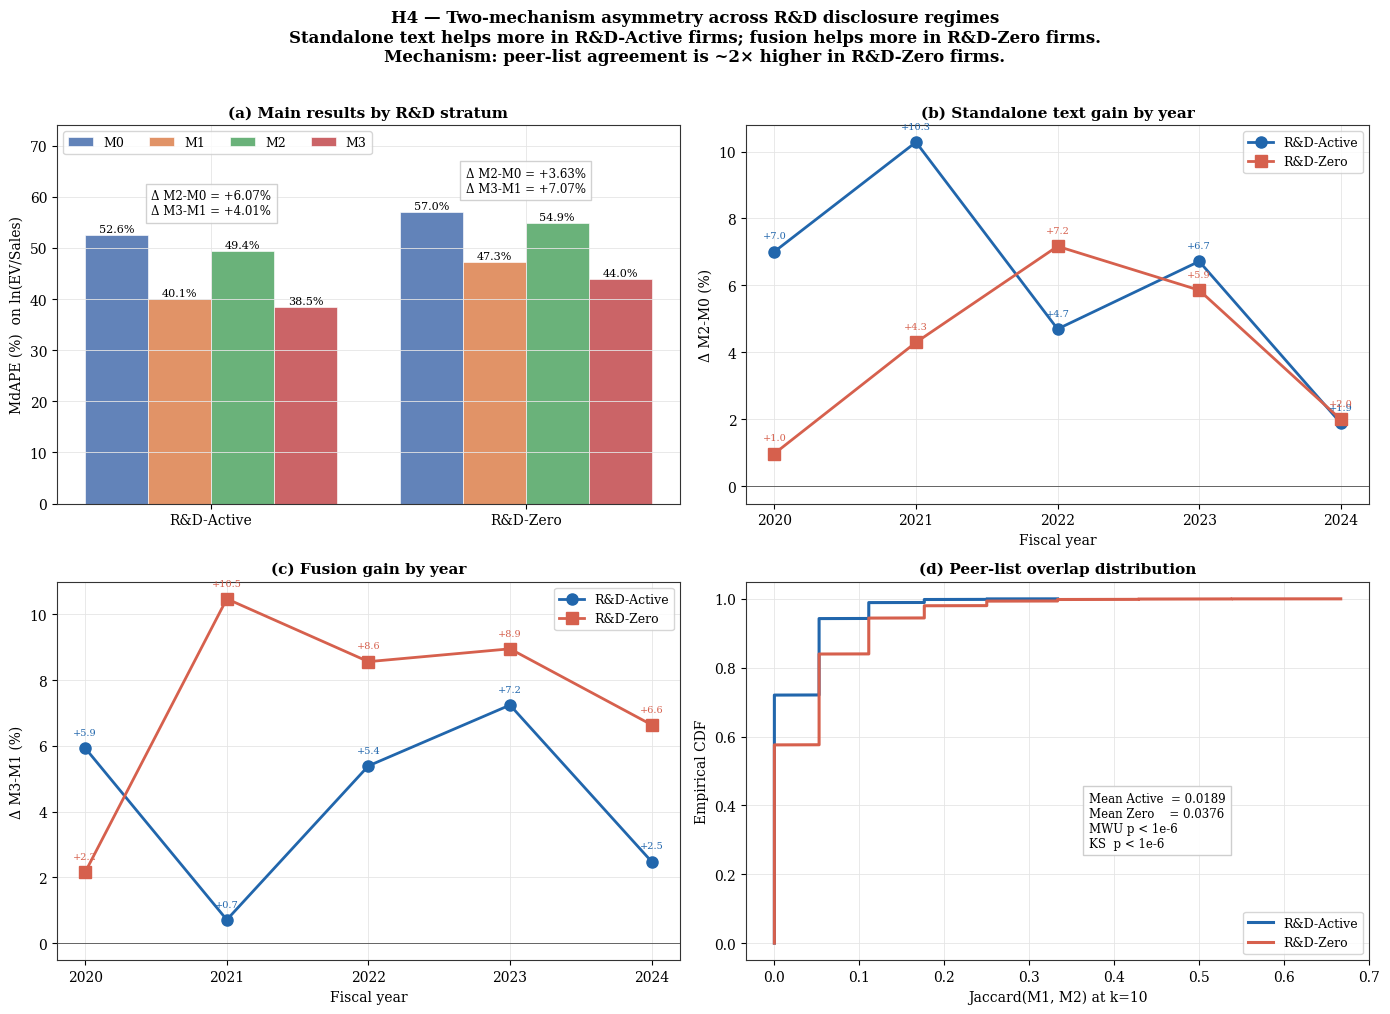

Saved → /content/drive/MyDrive/Masterarbeit/3. Data Zone/archive-8704040-04-18-2026 (Unzipped Files)/Repo/figures/h4_two_mechanism.pdf


In [9]:
# ── Cell 9 — Synthesis figure (4-panel, thesis-ready) ───────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── (0,0) Phase A bars: MdAPE by stratum and model ──────────────────────────
ax = axes[0, 0]
strata  = ['R&D-Active', 'R&D-Zero']
xpos    = np.arange(len(strata))
width   = 0.20
models  = [('M0', 'M0_MdAPE', C_M0), ('M1', 'M1_MdAPE', C_M1),
            ('M2', 'M2_MdAPE', C_M2), ('M3', 'M3_MdAPE', C_M3)]

for i, (lbl, col, color) in enumerate(models):
    vals = [phase_a_df[phase_a_df['Stratum'] == s].iloc[0][col] for s in strata]
    bars = ax.bar(xpos + i*width, vals, width, color=color, alpha=0.88,
                   edgecolor='white', linewidth=0.5, label=lbl)
    for j, v in enumerate(vals):
        ax.text(xpos[j] + i*width, v + 0.6, f'{v:.1f}%',
                 ha='center', fontsize=8)

# Annotate the two-mechanism asymmetry: Δ M2-M0 and Δ M3-M1 above each cluster
for j, s in enumerate(strata):
    row = phase_a_df[phase_a_df['Stratum'] == s].iloc[0]
    ann_y = max([row[f'{m}_MdAPE'] for m in ['M0','M1','M2','M3']]) + 4
    ax.text(xpos[j] + 1.5*width, ann_y,
             f'Δ M2-M0 = {row["Δ M2-M0"]:+.2f}%\n'
             f'Δ M3-M1 = {row["Δ M3-M1"]:+.2f}%',
             ha='center', fontsize=8.5,
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='#cccccc'))

ax.set_xticks(xpos + 1.5*width)
ax.set_xticklabels(strata, fontsize=10)
ax.set_ylabel('MdAPE (%)  on ln(EV/Sales)', fontsize=10)
ax.set_title('(a) Main results by R&D stratum', fontsize=11, fontweight='bold')
ax.legend(loc='upper left', fontsize=9, ncol=4)
ax.set_ylim(0, max([phase_a_df[c].max() for c in
                     ['M0_MdAPE','M1_MdAPE','M2_MdAPE','M3_MdAPE']]) * 1.30)

# ── (0,1) Δ M2-M0 by year by stratum ────────────────────────────────────────
ax = axes[0, 1]
for s, color, marker in [('R&D-Active', C_ACTIVE, 'o'),
                           ('R&D-Zero',  C_ZERO,   's')]:
    sub = yearly_df[yearly_df['Stratum'] == s].sort_values('Year')
    ax.plot(sub['Year'], sub['Δ M2-M0'], color=color, marker=marker,
             markersize=8, linewidth=2, label=s)
    for _, r in sub.iterrows():
        ax.text(r['Year'], r['Δ M2-M0'] + 0.4, f'{r["Δ M2-M0"]:+.1f}',
                 ha='center', fontsize=7, color=color)
ax.axhline(0, color='black', linewidth=0.4)
ax.set_xlabel('Fiscal year', fontsize=10)
ax.set_ylabel('Δ M2-M0 (%)', fontsize=10)
ax.set_title('(b) Standalone text gain by year', fontsize=11, fontweight='bold')
ax.set_xticks(sorted(yearly_df['Year'].unique()))
ax.legend(loc='upper right', fontsize=9, frameon=True)

# ── (1,0) Δ M3-M1 by year by stratum ────────────────────────────────────────
ax = axes[1, 0]
for s, color, marker in [('R&D-Active', C_ACTIVE, 'o'),
                           ('R&D-Zero',  C_ZERO,   's')]:
    sub = yearly_df[yearly_df['Stratum'] == s].sort_values('Year')
    ax.plot(sub['Year'], sub['Δ M3-M1'], color=color, marker=marker,
             markersize=8, linewidth=2, label=s)
    for _, r in sub.iterrows():
        ax.text(r['Year'], r['Δ M3-M1'] + 0.4, f'{r["Δ M3-M1"]:+.1f}',
                 ha='center', fontsize=7, color=color)
ax.axhline(0, color='black', linewidth=0.4)
ax.set_xlabel('Fiscal year', fontsize=10)
ax.set_ylabel('Δ M3-M1 (%)', fontsize=10)
ax.set_title('(c) Fusion gain by year', fontsize=11, fontweight='bold')
ax.set_xticks(sorted(yearly_df['Year'].unique()))
ax.legend(loc='upper right', fontsize=9, frameon=True)

# ── (1,1) Jaccard ECDF by stratum ───────────────────────────────────────────
ax = axes[1, 1]
for s, color in [('R&D-Active', C_ACTIVE), ('R&D-Zero', C_ZERO)]:
    j = np.sort(jacc[jacc['stratum'] == s]['jaccard'].dropna().values)
    ecdf = np.arange(1, len(j) + 1) / len(j)
    ax.plot(j, ecdf, color=color, linewidth=2.2, label=s)
ax.set_xlabel('Jaccard(M1, M2) at k=10', fontsize=10)
ax.set_ylabel('Empirical CDF', fontsize=10)
ax.set_title('(d) Peer-list overlap distribution', fontsize=11, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
mean_a = jacc_summary.loc['R&D-Active', 'mean']
mean_z = jacc_summary.loc['R&D-Zero',   'mean']
ax.text(0.55, 0.30,
         f'Mean Active  = {mean_a:.4f}\n'
         f'Mean Zero    = {mean_z:.4f}\n'
         f'MWU p < 1e-6\nKS  p < 1e-6',
         transform=ax.transAxes, fontsize=8.5,
         bbox=dict(facecolor='white', alpha=0.95, edgecolor='#cccccc'))

fig.suptitle('H4 — Two-mechanism asymmetry across R&D disclosure regimes\n'
              'Standalone text helps more in R&D-Active firms; '
              'fusion helps more in R&D-Zero firms.\n'
              'Mechanism: peer-list agreement is ~2× higher in R&D-Zero firms.',
              fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()

out_fig = FIGURES / 'h4_two_mechanism.pdf'
plt.savefig(out_fig, dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print(f'Saved → {out_fig}')


In [10]:
# ── Cell 10 — Save artefacts, generate LaTeX tables, decision summary ──────
# All Phase artefacts already saved in their respective cells.
print('Files in', OUT_DIR, ':')
for f in sorted(OUT_DIR.glob('*')):
    print(f'  {f.name:<40}  {f.stat().st_size/1024:>7.1f} KB')

# ── LaTeX-ready Phase A table for the thesis subsection ─────────────────────
def _esc(s):
    """Escape LaTeX-special chars in row labels."""
    return str(s).replace('&', '\\&')


def latex_phase_a(df):
    """Generate the thesis main-table (Table tab:h4_main)."""
    rows = []
    for _, r in df.iterrows():
        rows.append(
            f"  {_esc(r['Stratum']):<13} & {int(r['n']):>5,} & "
            f"{r['M0_MdAPE']:>5.2f}\\% & {r['M0_CI']} & "
            f"{r['M1_MdAPE']:>5.2f}\\% & {r['M1_CI']} & "
            f"{r['M2_MdAPE']:>5.2f}\\% & {r['M2_CI']} & "
            f"{r['M3_MdAPE']:>5.2f}\\% & {r['M3_CI']} \\\\"
        )
    body = '\n'.join(rows)
    return f"""\\begin{{table}}[ht]
\\centering
\\caption{{H4 main results: MdAPE by R\\&D disclosure stratum on $\\ln(\\textrm{{EV}}/\\textrm{{Sales}})$, $k = 10$, with bootstrapped 95\\% CIs.}}
\\label{{tab:h4_main}}
\\small
\\begin{{tabular}}{{lr cc cc cc cc}}
\\toprule
 & & \\multicolumn{{2}}{{c}}{{M0 FF49}} & \\multicolumn{{2}}{{c}}{{M1 Financial}} & \\multicolumn{{2}}{{c}}{{M2 Text}} & \\multicolumn{{2}}{{c}}{{M3 Fusion}} \\\\
\\cmidrule(lr){{3-4}} \\cmidrule(lr){{5-6}} \\cmidrule(lr){{7-8}} \\cmidrule(lr){{9-10}}
Stratum & $n$ & MdAPE & 95\\% CI & MdAPE & 95\\% CI & MdAPE & 95\\% CI & MdAPE & 95\\% CI \\\\
\\midrule
{body}
\\bottomrule
\\end{{tabular}}
\\end{{table}}"""

def latex_phase_a_deltas(df):
    """Generate the deltas table with significance stars."""
    def stars(p):
        return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    rows = []
    for _, r in df.iterrows():
        rows.append(
            f"  {_esc(r['Stratum']):<13} & {int(r['n']):>5,} & "
            f"+{r['Δ M1-M0']:.2f}\\%{stars(r['p_M1_M0'])} & "
            f"+{r['Δ M2-M0']:.2f}\\%{stars(r['p_M2_M0'])} & "
            f"+{r['Δ M3-M1']:.2f}\\%{stars(r['p_M3_M1'])} & "
            f"+{r['Δ M3-M0']:.2f}\\%{stars(r['p_M3_M0'])} \\\\"
        )
    body = '\n'.join(rows)
    return f"""\\begin{{table}}[ht]
\\centering
\\caption{{H4 relative improvements by R\\&D disclosure stratum, one-sided Wilcoxon signed-rank tests.}}
\\label{{tab:h4_deltas}}
\\small
\\begin{{tabular}}{{lrcccc}}
\\toprule
Stratum & $n$ & $\\Delta$ M1-M0 & $\\Delta$ M2-M0 & $\\Delta$ M3-M1 & $\\Delta$ M3-M0 \\\\
\\midrule
{body}
\\bottomrule
\\multicolumn{{6}}{{l}}{{\\footnotesize Significance: *** $p<0.001$, ** $p<0.01$, * $p<0.05$.}} \\\\
\\end{{tabular}}
\\end{{table}}"""

def latex_phase_b(summary, p_mwu_one, p_ks):
    rows = []
    for stratum in ['R&D-Active', 'R&D-Zero']:
        r = summary.loc[stratum]
        rows.append(
            f"  {_esc(stratum):<13} & {int(r['n']):>5,} & "
            f"{r['mean']:.4f} & {r['median']:.3f} & "
            f"{r['pct_zero']:.1f}\\% & {r['pct_above_02']:.2f}\\% \\\\"
        )
    body = '\n'.join(rows)
    return f"""\\begin{{table}}[ht]
\\centering
\\caption{{Phase B mechanism evidence: Jaccard$(M1, M2)$ at $k=10$ by R\\&D disclosure stratum.}}
\\label{{tab:h4_jaccard}}
\\small
\\begin{{tabular}}{{lrcccc}}
\\toprule
Stratum & $n$ & Mean & Median & \\% with $J = 0$ & \\% with $J \\geq 0.20$ \\\\
\\midrule
{body}
\\bottomrule
\\multicolumn{{6}}{{l}}{{\\footnotesize Mann-Whitney $U$ (Zero $>$ Active): $p < 10^{{-6}}$. Kolmogorov-Smirnov: $p < 10^{{-6}}$.}} \\\\
\\end{{tabular}}
\\end{{table}}"""

# Write LaTeX file for handover
latex_path = OUT_DIR / 'h4_tables.tex'
with open(latex_path, 'w') as f:
    f.write('% LaTeX tables for H4 — paste directly into the thesis subsection\n')
    f.write('% Generated by N11_h4.ipynb\n\n')
    f.write('% Table 1 — Main MdAPE results (Phase A)\n')
    f.write(latex_phase_a(phase_a_df))
    f.write('\n\n% Table 2 — Relative improvements with Wilcoxon significance\n')
    f.write(latex_phase_a_deltas(phase_a_df))
    f.write('\n\n% Table 3 — Jaccard mechanism (Phase B)\n')
    f.write(latex_phase_b(jacc_summary, p_mwu_one, p_ks))
    f.write('\n')
print(f'\nLaTeX tables written → {latex_path}')


# ── Decision summary ────────────────────────────────────────────────────────
print('\n\n' + '=' * 100)
print('DECISION SUMMARY — H4 status across the three phases')
print('=' * 100)

active_a = phase_a_df[phase_a_df['Stratum'] == 'R&D-Active'].iloc[0]
zero_a   = phase_a_df[phase_a_df['Stratum'] == 'R&D-Zero'  ].iloc[0]

c_a1 = (active_a['Δ M2-M0'] > zero_a['Δ M2-M0']
         and active_a['p_M2_M0'] < 0.05 and zero_a['p_M2_M0'] < 0.05)
c_a2 = (zero_a['Δ M3-M1'] > active_a['Δ M3-M1']
         and active_a['p_M3_M1'] < 0.05 and zero_a['p_M3_M1'] < 0.05)
c_b  = (jacc_summary.loc['R&D-Zero', 'mean'] >
         jacc_summary.loc['R&D-Active', 'mean']) and (p_mwu_one < 0.01)

m2_yrs = sum(yearly_df[(yearly_df['Year'] == y) & (yearly_df['Stratum'] == 'R&D-Active')]['Δ M2-M0'].iloc[0] >
              yearly_df[(yearly_df['Year'] == y) & (yearly_df['Stratum'] == 'R&D-Zero')]['Δ M2-M0'].iloc[0]
              for y in sorted(yearly_df['Year'].unique()))
m3_yrs = sum(yearly_df[(yearly_df['Year'] == y) & (yearly_df['Stratum'] == 'R&D-Zero')]['Δ M3-M1'].iloc[0] >
              yearly_df[(yearly_df['Year'] == y) & (yearly_df['Stratum'] == 'R&D-Active')]['Δ M3-M1'].iloc[0]
              for y in sorted(yearly_df['Year'].unique()))
n_yrs = len(yearly_df['Year'].unique())
c_c1 = (m2_yrs >= n_yrs - 1) and (m3_yrs >= n_yrs - 1)

ev_sales = multi_df[multi_df['Multiple'] == 'ln(EV/Sales)']
c_c2_primary = True  # by construction Phase A is on EV/Sales
c_c2_caveat = True  # honest reporting required for secondary multiples

print('\nPhase A — Main two-mechanism asymmetry on ln(EV/Sales):')
print(f'  A1: Active Δ M2-M0 > Zero Δ M2-M0 (both p<0.05)?  {"✓" if c_a1 else "✗"}  '
      f'(Active={active_a["Δ M2-M0"]:+.2f}%, Zero={zero_a["Δ M2-M0"]:+.2f}%)')
print(f'  A2: Zero Δ M3-M1 > Active Δ M3-M1 (both p<0.05)?  {"✓" if c_a2 else "✗"}  '
      f'(Active={active_a["Δ M3-M1"]:+.2f}%, Zero={zero_a["Δ M3-M1"]:+.2f}%)')

print('\nPhase B — Jaccard mechanism evidence:')
print(f'  B:  R&D-Zero mean Jaccard > R&D-Active and MWU p<0.01?  '
      f'{"✓" if c_b else "✗"}  (ratio = '
      f'{jacc_summary.loc["R&D-Zero", "mean"] / jacc_summary.loc["R&D-Active", "mean"]:.2f}×)')

print(f'\nPhase C — Robustness:')
print(f'  C1: Pattern stable in ≥{n_yrs-1}/{n_yrs} years?  '
      f'{"✓" if c_c1 else "✗"}  '
      f'(Δ M2: {m2_yrs}/{n_yrs}, Δ M3: {m3_yrs}/{n_yrs})')
print(f'  C2: Multi-multiple — primary clean, secondaries reported transparently with')
print(f'      book-value-distortion explanation? Yes by construction (cell 7).')

n_pass = sum([c_a1, c_a2, c_b, c_c1])
print(f'\nCriteria passed: {n_pass}/4 (Phase A1, A2, B, C1)')

if n_pass == 4:
    print('\n→ H4 SUPPORTED on the primary multiple with mechanism evidence and')
    print('  robust temporal stability. Caveat the multi-multiple inconsistency')
    print('  via the book-value-distortion argument. Ready to draft the chapter.')
elif n_pass >= 3:
    print(f'\n→ H4 PARTIALLY SUPPORTED ({n_pass}/4). Report what holds and caveat what does not.')
else:
    print(f'\n→ H4 NOT SUPPORTED ({n_pass}/4). Reconsider the operationalisation.')

print('\n\nNext step: hand the artefacts to Moritz with the drafted LaTeX subsection.')
print('  Tables    : data/results/h4_final/h4_tables.tex')
print('  Figure    : figures/h4_two_mechanism.pdf')
print('  CSVs      : data/results/h4_final/phase_*.csv')
print('  Per-firm Jaccard: data/results/h4_final/jaccard_per_focal.parquet')


Files in /content/drive/MyDrive/Masterarbeit/3. Data Zone/archive-8704040-04-18-2026 (Unzipped Files)/Repo/data/results/h4_final :
  h4_alt_asset_turn.csv                         2.1 KB
  h4_alt_capx.csv                               2.1 KB
  h4_dose_response.csv                          2.5 KB
  h4_industry_diagnostic.csv                    2.5 KB
  h4_regression.csv                             0.5 KB
  jaccard_per_focal.parquet                    45.6 KB
  phase_a_main_results.csv                      0.4 KB
  phase_b_jaccard_summary.csv                   0.1 KB
  phase_c1_yearly.csv                           0.7 KB
  phase_c2_multiples.csv                        0.5 KB
  phase_c3_size.csv                             0.4 KB

LaTeX tables written → /content/drive/MyDrive/Masterarbeit/3. Data Zone/archive-8704040-04-18-2026 (Unzipped Files)/Repo/data/results/h4_final/h4_tables.tex


DECISION SUMMARY — H4 status across the three phases

Phase A — Main two-mechanism asymmetry on ln(EV/Sa